# ChEMBL
- 화합물 데이터베이스 중 하나입니다. 특정 화합물이나 증상같은걸로 검색하면 관련된 화합물을 찾아주는 서비스입니다.
- 검색 결과를 csv 파일로 저장할 수 있습니다.
- 뭐 가져오는 라이브러리도 있는 것 같은데 오늘은 예전에 받아뒀던거 걍 쓸겁니다. 

## 프로젝트 정보
- 인원: 1인
- 파이썬 버전: 3.10
- 데이터 리소스: ChEMBL
- 필요한 모듈: Numpy, Pandas, Matplotlib, Seaborn

In [49]:
# 모! 듈! 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from chembl_webresource_client.new_client import new_client # 켐블털이 
from scipy import stats # 통계분석용

# 그래프 기본 테마 설정
sns.set_theme(palette="viridis", style="whitegrid", font_scale=1) # 블루톤

# 그래프를 그리기 위한 기본 설정
plt.rcParams['font.family'] = 'Galmuri14' # 제가... 픽셀체 이런거 좋아해서... 
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['axes.titlesize'] = 16 # 제목 폰트 사이즈
plt.rcParams['axes.labelsize'] = 14 # 라벨 폰트 사이즈
plt.rcParams['font.size'] = 14 # 기본 폰트사이즈 
plt.rcParams['axes.unicode_minus'] = False

In [2]:
data_df = pd.read_csv("data/Ibuprofen.csv", sep=";") # 구분자가 ;
data_df

,ChEMBL ID,Name,Synonyms,Type,Max Phase,Molecular Weight,Targets,Bioactivities,AlogP,Polar Surface Area,...,Heavy Atoms,Np Likeness Score,Molecular Formula,Smiles,Inchi Key,Inchi,Withdrawn Flag,Orphan,Records Key,Records Name
0,CHEMBL253765,(R)-SUPROFEN,NaN,Small molecule,NaN,260.31,12.0,15.0,3.17,54.37,...,18,-0.81,C14H12O3S,C[C@@H](C(=O)O)c1ccc(C(=O)c2cccs2)cc1,MDKGKXOCJGEUJW-SECBINFHSA-N,InChI=1S/C14H12O3S/c1-9(14(16)17)10-4-6-11(7-5...,False,-1,"['SID11112759', '212, suprofen (R)', 'Suprofen...","['SID11112759', '(R)-2-(4-(thiophene-5-carbony..."
1,CHEMBL2104170,CLIPROFEN,"CLIPROFEN|CLIPROFENE|CLIPROFENO|R-25,160|R-25160",Small molecule,2.0,294.76,NaN,NaN,3.82,54.37,...,19,-1.23,C14H11ClO3S,CC(C(=O)O)c1ccc(C(=O)c2cccs2)c(Cl)c1,NLGUJWNOGYWZBI-UHFFFAOYSA-N,InChI=1S/C14H11ClO3S/c1-8(14(17)18)9-4-5-10(11...,False,0,"['CLIPROFEN', 'CLIPROFEN']","['CLIPROFEN', 'CLIPROFEN']"
2,CHEMBL2107442,LOBUPROFEN,LOBUPROFEN|LOBUPROFENE|LOBUPROFENO,Small molecule,2.0,429.00,NaN,NaN,5.01,32.78,...,30,-1.12,C25H33ClN2O2,CC(C)Cc1ccc(C(C)C(=O)OCCN2CCN(c3cccc(Cl)c3)CC2...,JFGXBHHLHQAGRR-UHFFFAOYSA-N,InChI=1S/C25H33ClN2O2/c1-19(2)17-21-7-9-22(10-...,False,0,['LOBUPROFEN'],['LOBUPROFEN']
3,CHEMBL4297164,XIMOPROFEN,XIMOPROFEN|XIMOPROFENE|XIMOPROFENO,Small molecule,2.0,261.32,1.0,1.0,3.36,69.89,...,19,0.16,C15H19NO3,CC(C(=O)O)c1ccc(C2CCCC(=NO)C2)cc1,IQPPOXSMSDPZKU-UHFFFAOYSA-N,InChI=1S/C15H19NO3/c1-10(15(17)18)11-5-7-12(8-...,False,0,"['Ximoprofen', 'XIMOPROFEN']","['Ximoprofen', 'XIMOPROFEN']"
4,CHEMBL2107432,LOSMIPROFEN,LOSMIPROFEN|LOSMIPROFENE|LOSMIPROFENO,Small molecule,2.0,318.76,NaN,NaN,3.73,63.60,...,22,-0.76,C17H15ClO4,Cc1c(OC(C)C(=O)O)cccc1C(=O)c1ccc(Cl)cc1,JQYJAGNNCNBFRM-UHFFFAOYSA-N,InChI=1S/C17H15ClO4/c1-10-14(16(19)12-6-8-13(1...,False,0,['LOSMIPROFEN'],['LOSMIPROFEN']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,CHEMBL341922,KETOPROFEN SODIUM,DIRACTIN|KETOPROFEN SODIUM|SODIUM KETOPROFEN,Small molecule,2.0,276.27,2.0,7.0,3.11,54.37,...,19,-0.08,C16H13NaO3,CC(C(=O)[O-])c1cccc(C(=O)c2ccccc2)c1.[Na+],OAPDLBHLMVYMCW-UHFFFAOYSA-M,InChI=1S/C16H14O3.Na/c1-11(16(18)19)13-8-5-9-1...,False,0,"['32', 'KETOPROFEN SODIUM']",['Sodium salt 2-(3-benzoyl-phenyl)-propionate'...
59,CHEMBL2106966,PIKETOPROFEN,CALMATEL|PIKETOPROFEN|PIKETOPROFENE|PIKETOPROFENO,Small molecule,2.0,344.41,3.0,7.0,4.36,59.06,...,26,-1.02,C22H20N2O2,Cc1ccnc(NC(=O)C(C)c2cccc(C(=O)c3ccccc3)c2)c1,ASFKKFRSMGBFRO-UHFFFAOYSA-N,InChI=1S/C22H20N2O2/c1-15-11-12-23-20(13-15)24...,False,0,"['PIKETOPROFEN', 'PIKETOPROFEN', 'piketoprofen...","['PIKETOPROFEN', 'PIKETOPROFEN', 'piketoprofen..."
60,CHEMBL1297,FENOPROFEN,53858|FENOPROFEN|FENOPROFENE|FENOPROFENO|LILLY...,Small molecule,4.0,242.27,145.0,719.0,3.67,46.53,...,18,-0.26,C15H14O3,CC(C(=O)O)c1cccc(Oc2ccccc2)c1,RDJGLLICXDHJDY-UHFFFAOYSA-N,InChI=1S/C15H14O3/c1-11(15(16)17)12-6-5-9-14(1...,False,0,"['780', 'fenoprofen', '(R,S)-Fenoprofen', 'Fen...","[None, 'fenoprofen', 'Fenoprofen', 'Fenoprofen..."
61,CHEMBL188952,PIRPROFEN,PIRPROFEN|PIRPROFENE|PIRPROFENO|RACEMIC PIRPRO...,Small molecule,4.0,251.71,92.0,163.0,2.90,40.54,...,17,-0.53,C13H14ClNO2,CC(C(=O)O)c1ccc(N2CC=CC2)c(Cl)c1,PIDSZXPFGCURGN-UHFFFAOYSA-N,InChI=1S/C13H14ClNO2/c1-9(13(16)17)10-4-5-12(1...,True,0,"['Pirprofen', 'Pirprofen (table 1)', 'PIRPROFE...","['Pirprofen', '2-[3-Chloro-4-(2,5-dihydro-pyrr..."


# 데이터 정보 확인

## df.shape

In [3]:
data_df.shape

(63, 29)

## df.info()

In [4]:
data_df.info() # 얼마 되지도 않는거에 널까지 껴있네 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ChEMBL ID           63 non-null     object 
 1   Name                62 non-null     object 
 2   Synonyms            59 non-null     object 
 3   Type                63 non-null     object 
 4   Max Phase           59 non-null     float64
 5   Molecular Weight    63 non-null     float64
 6   Targets             40 non-null     float64
 7   Bioactivities       40 non-null     float64
 8   AlogP               63 non-null     float64
 9   Polar Surface Area  63 non-null     float64
 10  HBA                 63 non-null     int64  
 11  HBD                 63 non-null     int64  
 12  #RO5 Violations     63 non-null     int64  
 13  #Rotatable Bonds    63 non-null     int64  
 14  Passes Ro3          63 non-null     object 
 15  QED Weighted        63 non-null     float64
 16  Aromatic R

## df.describe()

In [5]:
data_df.describe()
# 여기 나왔어도 범주형인것도 있습니다. 

,Max Phase,Molecular Weight,Targets,Bioactivities,AlogP,Polar Surface Area,HBA,HBD,#RO5 Violations,#Rotatable Bonds,QED Weighted,Aromatic Rings,Inorganic Flag,Heavy Atoms,Np Likeness Score,Orphan
count,59.000000,63.000000,40.000000,40.00000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000
mean,2.474576,286.804603,61.400000,282.35000,3.535079,48.665238,2.317460,0.968254,0.063492,3.984127,0.803175,1.841270,-0.063492,19.571429,-0.363492,-0.063492
std,1.164947,64.184537,87.147914,691.58282,0.694833,11.659890,1.044577,0.567060,0.245805,1.539712,0.097299,0.676956,0.245805,3.509040,0.536603,0.245805
min,-1.000000,206.280000,1.000000,1.00000,2.100000,29.540000,1.000000,0.000000,0.000000,2.000000,0.490000,1.000000,-1.000000,15.000000,-1.510000,-1.000000
25%,2.000000,248.805000,2.000000,5.75000,3.070000,37.300000,1.000000,1.000000,0.000000,3.000000,0.755000,1.000000,0.000000,18.000000,-0.785000,0.000000
50%,2.000000,266.300000,8.500000,16.00000,3.430000,49.850000,2.000000,1.000000,0.000000,4.000000,0.820000,2.000000,0.000000,19.000000,-0.420000,0.000000
75%,4.000000,300.045000,102.750000,239.75000,3.825000,54.485000,3.000000,1.000000,0.000000,4.000000,0.865000,2.000000,0.000000,21.000000,0.070000,0.000000
max,4.000000,558.640000,375.000000,4089.00000,5.880000,86.630000,5.000000,3.000000,1.000000,9.000000,0.940000,3.000000,0.000000,33.000000,0.920000,0.000000


In [6]:
data_df.describe(include="O")

,ChEMBL ID,Name,Synonyms,Type,Passes Ro3,Structure Type,Molecular Formula,Smiles,Inchi Key,Inchi,Records Key,Records Name
count,63,62,59,63,63,63,63,63,63,63,63,63
unique,63,62,59,1,2,1,53,63,63,63,63,63
top,CHEMBL253765,(R)-SUPROFEN,"CLIPROFEN|CLIPROFENE|CLIPROFENO|R-25,160|R-25160",Small molecule,N,MOL,C14H12O3S,C[C@@H](C(=O)O)c1ccc(C(=O)c2cccs2)cc1,MDKGKXOCJGEUJW-SECBINFHSA-N,InChI=1S/C14H12O3S/c1-9(14(16)17)10-4-6-11(7-5...,"['SID11112759', '212, suprofen (R)', 'Suprofen...","['SID11112759', '(R)-2-(4-(thiophene-5-carbony..."
freq,1,1,1,63,61,63,3,1,1,1,1,1


## df.isna().sum()

In [7]:
data_df.isna().sum() 
# 아 널이예요... 
# 근데 이 널은 우리가 몰라서 못 채워요... 

ChEMBL ID              0
Name                   1
Synonyms               4
Type                   0
Max Phase              4
Molecular Weight       0
Targets               23
Bioactivities         23
AlogP                  0
Polar Surface Area     0
HBA                    0
HBD                    0
#RO5 Violations        0
#Rotatable Bonds       0
Passes Ro3             0
QED Weighted           0
Aromatic Rings         0
Structure Type         0
Inorganic Flag         0
Heavy Atoms            0
Np Likeness Score      0
Molecular Formula      0
Smiles                 0
Inchi Key              0
Inchi                  0
Withdrawn Flag         0
Orphan                 0
Records Key            0
Records Name           0
dtype: int64

## df.head()

In [8]:
data_df.head()

,ChEMBL ID,Name,Synonyms,Type,Max Phase,Molecular Weight,Targets,Bioactivities,AlogP,Polar Surface Area,...,Heavy Atoms,Np Likeness Score,Molecular Formula,Smiles,Inchi Key,Inchi,Withdrawn Flag,Orphan,Records Key,Records Name
0,CHEMBL253765,(R)-SUPROFEN,NaN,Small molecule,NaN,260.31,12.0,15.0,3.17,54.37,...,18,-0.81,C14H12O3S,C[C@@H](C(=O)O)c1ccc(C(=O)c2cccs2)cc1,MDKGKXOCJGEUJW-SECBINFHSA-N,InChI=1S/C14H12O3S/c1-9(14(16)17)10-4-6-11(7-5...,False,-1,"['SID11112759', '212, suprofen (R)', 'Suprofen...","['SID11112759', '(R)-2-(4-(thiophene-5-carbony..."
1,CHEMBL2104170,CLIPROFEN,"CLIPROFEN|CLIPROFENE|CLIPROFENO|R-25,160|R-25160",Small molecule,2.0,294.76,NaN,NaN,3.82,54.37,...,19,-1.23,C14H11ClO3S,CC(C(=O)O)c1ccc(C(=O)c2cccs2)c(Cl)c1,NLGUJWNOGYWZBI-UHFFFAOYSA-N,InChI=1S/C14H11ClO3S/c1-8(14(17)18)9-4-5-10(11...,False,0,"['CLIPROFEN', 'CLIPROFEN']","['CLIPROFEN', 'CLIPROFEN']"
2,CHEMBL2107442,LOBUPROFEN,LOBUPROFEN|LOBUPROFENE|LOBUPROFENO,Small molecule,2.0,429.00,NaN,NaN,5.01,32.78,...,30,-1.12,C25H33ClN2O2,CC(C)Cc1ccc(C(C)C(=O)OCCN2CCN(c3cccc(Cl)c3)CC2...,JFGXBHHLHQAGRR-UHFFFAOYSA-N,InChI=1S/C25H33ClN2O2/c1-19(2)17-21-7-9-22(10-...,False,0,['LOBUPROFEN'],['LOBUPROFEN']
3,CHEMBL4297164,XIMOPROFEN,XIMOPROFEN|XIMOPROFENE|XIMOPROFENO,Small molecule,2.0,261.32,1.0,1.0,3.36,69.89,...,19,0.16,C15H19NO3,CC(C(=O)O)c1ccc(C2CCCC(=NO)C2)cc1,IQPPOXSMSDPZKU-UHFFFAOYSA-N,InChI=1S/C15H19NO3/c1-10(15(17)18)11-5-7-12(8-...,False,0,"['Ximoprofen', 'XIMOPROFEN']","['Ximoprofen', 'XIMOPROFEN']"
4,CHEMBL2107432,LOSMIPROFEN,LOSMIPROFEN|LOSMIPROFENE|LOSMIPROFENO,Small molecule,2.0,318.76,NaN,NaN,3.73,63.60,...,22,-0.76,C17H15ClO4,Cc1c(OC(C)C(=O)O)cccc1C(=O)c1ccc(Cl)cc1,JQYJAGNNCNBFRM-UHFFFAOYSA-N,InChI=1S/C17H15ClO4/c1-10-14(16(19)12-6-8-13(1...,False,0,['LOSMIPROFEN'],['LOSMIPROFEN']


## df.columns

In [9]:
data_df.columns

Index(['ChEMBL ID', 'Name', 'Synonyms', 'Type', 'Max Phase',
       'Molecular Weight', 'Targets', 'Bioactivities', 'AlogP',
       'Polar Surface Area', 'HBA', 'HBD', '#RO5 Violations',
       '#Rotatable Bonds', 'Passes Ro3', 'QED Weighted', 'Aromatic Rings',
       'Structure Type', 'Inorganic Flag', 'Heavy Atoms', 'Np Likeness Score',
       'Molecular Formula', 'Smiles', 'Inchi Key', 'Inchi', 'Withdrawn Flag',
       'Orphan', 'Records Key', 'Records Name'],
      dtype='object')

# 전처리

## 분자량 범주화
- 500보다 큰가, 작은가로 나눌거다. 
- 왜냐고요? RO5(리핀스키의 Rule of 5)에 따라 500보다 큰 분자는 거의 약이 아니기 때문임. 

In [10]:
# 분자량이 500보다 크면 헤비 아니면 라이트
data_df['Moecular_classification'] = data_df['Molecular Weight'].apply(lambda x: 'Heavy' if x > 500 else 'Light') 

## Max Phase 범주화
- 4 아니면 다 임상중인겁니다. -1은... 어... 힘내라... 

In [11]:
# 4: Approved/3~0: Clinical/-1: Failed
data_df['Status'] = data_df['Max Phase'].map({4: 'Approved', 3: 'Clinical', 2: 'Clinical', 1: 'Clinical', 0: 'Clinical', -1: 'Failed'}) 
# 아니 맵합수가 왜 여기서

In [12]:
data_df['Status'].value_counts()

Status
Clinical    40
Approved    17
Failed       2
Name: count, dtype: int64

# 본게임은 지금부터다

## Max phase별로 보기

### Max phase에 따른 상태별 분자량 평균

In [16]:
data_df.groupby('Status')['Molecular Weight'].mean() # 평균

Status
Approved    279.101176
Clinical    293.348500
Failed      272.860000
Name: Molecular Weight, dtype: float64

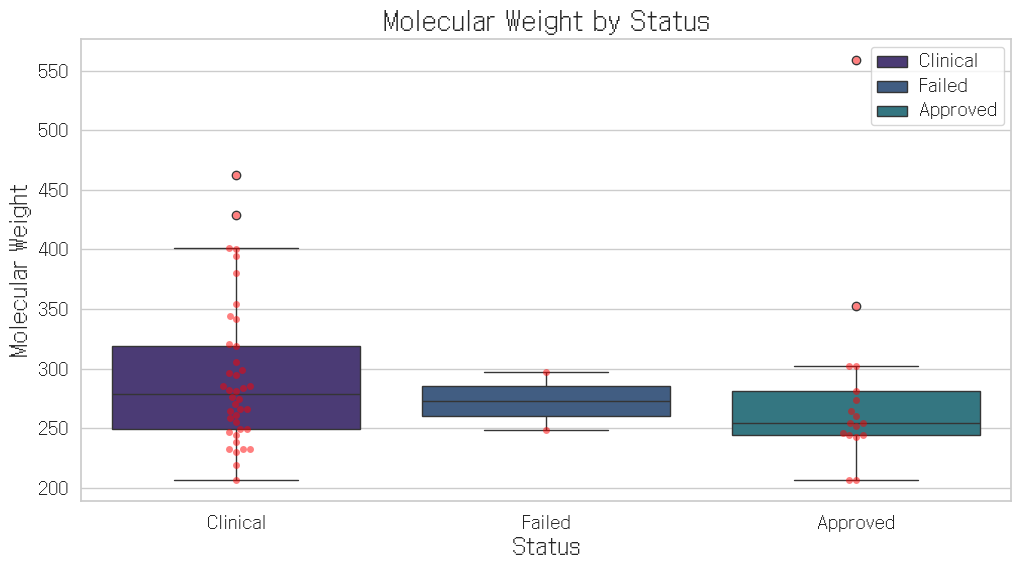

In [38]:
# boxplot
sns.boxplot(data_df, x = 'Status', y = 'Molecular Weight', hue = 'Status')
sns.swarmplot(data=data_df, x='Status', y='Molecular Weight', color='red', alpha=0.5)
plt.title('Molecular Weight by Status')
plt.show()

- Approved에 저 이상치 뭐냐? 500을 넘겼네? 
- Clinical은 아직 임상 진행중인 약물들이라 배리에이션이 다양하고, Failed는 어... 모종의 이유로 엎은거다. 분자량 때문은 아닌 듯 하지만. 

### 이상치가 있네?

In [30]:
data_df.query('`Molecular Weight` > 500').index # 40번이 나왔다
data_df[['Name','Molecular Weight','Molecular Formula', 'Smiles']].loc[40] # FENOPROFEN CALCIUM (분자량 558.64)

Name                                                FENOPROFEN CALCIUM
Molecular Weight                                                558.64
Molecular Formula                                           C30H30CaO8
Smiles               CC(C(=O)[O-])c1cccc(Oc2ccccc2)c1.CC(C(=O)[O-])...
Name: 40, dtype: object

- FENOPROFEN CALCIUM에 대해 찾아보니 쟤가 구조상 카복실산이 달려있음. 
- 칼슘이 옆구리에 쟤를 하나씩 끼고 있어서 분자량이 커진거지, 개별 분자량은 작은 편. 

In [37]:
# clinical에도 이상치가 있더라? 
idx_list = data_df.query('`Molecular Weight` > 400 and Status == "Clinical"').index # 2, 13, 14, 34
for idx in idx_list:
    display(data_df[['Name','Molecular Weight','Molecular Formula', 'Smiles','Max Phase']].loc[idx])

Name                                                        LOBUPROFEN
Molecular Weight                                                 429.0
Molecular Formula                                         C25H33ClN2O2
Smiles               CC(C)Cc1ccc(C(C)C(=O)OCCN2CCN(c3cccc(Cl)c3)CC2...
Max Phase                                                          2.0
Name: 2, dtype: object

Name                                                       FRABUPROFEN
Molecular Weight                                                462.56
Molecular Formula                                         C26H33F3N2O2
Smiles               CC(C)Cc1ccc(C(C)C(=O)OCCN2CCN(c3cccc(C(F)(F)F)...
Max Phase                                                          2.0
Name: 13, dtype: object

Name                                                 KETOPROFEN LYSINE
Molecular Weight                                                400.48
Molecular Formula                                           C22H28N2O5
Smiles               CC(C(=O)O)c1cccc(C(=O)c2ccccc2)c1.NCCCC[C@H](N...
Max Phase                                                          1.0
Name: 14, dtype: object

Name                                                       BIFEPROFEN
Molecular Weight                                               400.91
Molecular Formula                                        C22H25ClN2O3
Smiles               CC(C(=O)OCC(=O)N1CCN(C)CC1)c1ccc(-c2ccccc2Cl)cc1
Max Phase                                                         2.0
Name: 34, dtype: object

- 임상 단계에 있는 약물중에는 뭐 붙어있는 애들이 좀 많다. 라이신 뭐 이런거. 

In [41]:
# 실패한 칭구칭긔들
idx_list = data_df.query('Status == "Failed"').index # 23, 27
for idx in idx_list:
    display(data_df[['Name','Molecular Weight','Molecular Formula', 'Smiles','Max Phase']].loc[idx])

Name                                   IBUPROFEN PICONOL
Molecular Weight                                   297.4
Molecular Formula                              C19H23NO2
Smiles               CC(C)Cc1ccc(C(C)C(=O)OCc2ccccn2)cc1
Max Phase                                           -1.0
Name: 23, dtype: object

Name                                   LOXOPROFEN TRANS ALCOHOL
Molecular Weight                                         248.32
Molecular Formula                                      C15H20O3
Smiles               C[C@H](C(=O)O)c1ccc(C[C@H]2CCC[C@@H]2O)cc1
Max Phase                                                  -1.0
Name: 27, dtype: object

## Bioactivity

In [43]:
data_df.groupby('Status')['Bioactivities'].mean() # 평균

Status
Approved    680.666667
Clinical     53.052632
Failed       24.500000
Name: Bioactivities, dtype: float64

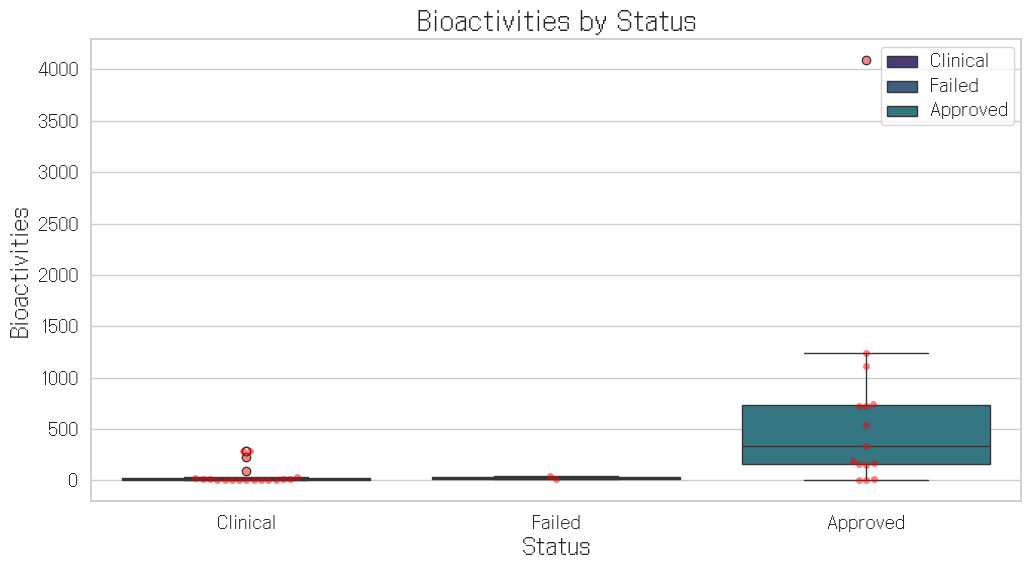

In [45]:
# boxplot
sns.boxplot(data_df, x = 'Status', y = 'Bioactivities', hue = 'Status')
sns.swarmplot(data=data_df, x='Status', y='Bioactivities', color='red', alpha=0.5)
plt.title('Bioactivities by Status')
plt.show()

- 저 4000 저거 누구냐. 

### 이상치 범인 찾기

In [ ]:
data_df.query('Bioactivities > 4000').index # 50
data_df[['Name','Molecular Weight','Molecular Formula', 'Bioactivities', 'Smiles']].loc[50] # IBUPROFEN

Name                                  IBUPROFEN
Molecular Weight                         206.28
Molecular Formula                      C13H18O2
Bioactivities                            4089.0
Smiles               CC(C)Cc1ccc(C(C)C(=O)O)cc1
Name: 50, dtype: object

- 아... 원조가 제일 쎄네... 

### 맨 휘트니 분석
- 저기 Clinical하고 Failed간에 차이가 있는지를 한번 검정해보자. 

In [51]:
# 맨 휫흐니 검정을 할거예요 
# 얘네는 수가 적어서 t-test 못해요 
clinical_vals = data_df[data_df['Status'] == 'Clinical']['Bioactivities'].dropna() # 클리니컬
failed_vals = data_df[data_df['Status'] == 'Failed']['Bioactivities'].dropna() # 엎음

u_stat, p_val = stats.mannwhitneyu(clinical_vals, failed_vals, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_stat}")
print(f"P-value: {p_val}")

if p_val < 0.05:
    print("결과: 두 그룹 간에 통계적으로 유의미한 차이가 있습니다! (다른 놈임)")
else:
    print("결과: P-value가 0.05보다 큽니다. 두 그룹은 통계적으로 '그놈이 그놈'입니다.")

Mann-Whitney U statistic: 12.0
P-value: 0.43372561703125134
결과: P-value가 0.05보다 큽니다. 두 그룹은 통계적으로 '그놈이 그놈'입니다.


### AlogP

In [52]:
data_df.groupby('Status')['AlogP'].mean() # 평균

Status
Approved    3.369412
Clinical    3.675500
Failed      3.355000
Name: AlogP, dtype: float64

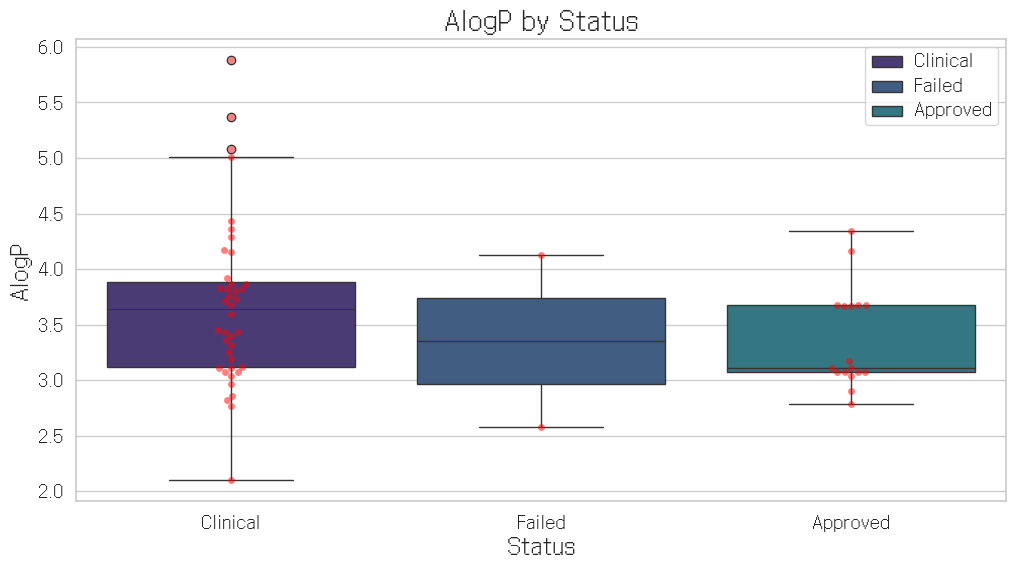

In [55]:
# boxplot
sns.boxplot(data_df, x = 'Status', y = 'AlogP', hue = 'Status')
sns.swarmplot(data=data_df, x='Status', y='AlogP', color='red', alpha=0.5)
plt.title('AlogP by Status')
plt.show()

- 승인된 약물은 전체적으로 뚜껑 아니면 바닥인데 임상 진행중인 약물들에 이상치가 보인다. 
- 이거 logP가 너무 높아도 안될건데... (너무 기름져서 물에 안녹음)

### 이상치 누구냐

In [59]:
# 이상치를 찾아라 
idx_list = data_df.query('AlogP >= 5').index # 2, 13, 21, 57
for idx in idx_list:
    display(data_df[['Name','Molecular Weight','Molecular Formula', 'Smiles','AlogP', 'Max Phase']].loc[idx])

Name                                                        LOBUPROFEN
Molecular Weight                                                 429.0
Molecular Formula                                         C25H33ClN2O2
Smiles               CC(C)Cc1ccc(C(C)C(=O)OCCN2CCN(c3cccc(Cl)c3)CC2...
AlogP                                                             5.01
Max Phase                                                          2.0
Name: 2, dtype: object

Name                                                       FRABUPROFEN
Molecular Weight                                                462.56
Molecular Formula                                         C26H33F3N2O2
Smiles               CC(C)Cc1ccc(C(C)C(=O)OCCN2CCN(c3cccc(C(F)(F)F)...
AlogP                                                             5.37
Max Phase                                                          2.0
Name: 13, dtype: object

Name                                                      TIOXAPROFEN
Molecular Weight                                               394.28
Molecular Formula                                       C18H13Cl2NO3S
Smiles               CC(Sc1nc(-c2ccc(Cl)cc2)c(-c2ccc(Cl)cc2)o1)C(=O)O
AlogP                                                            5.88
Max Phase                                                         2.0
Name: 21, dtype: object

Name                                         VEDAPROFEN
Molecular Weight                                 282.38
Molecular Formula                              C19H22O2
Smiles               CC(C(=O)O)c1ccc(C2CCCCC2)c2ccccc12
AlogP                                              5.08
Max Phase                                           2.0
Name: 57, dtype: object

- VEDAPROFEN은 동물용 소염진통제다. 
- TIOXAPROFEN은 항진균제인데, 바르는 용도다. 음... 그럼 확실히 피부를 통해서 인지질 이중층을 공략하는쪽이 더 낫겠군. 

## Withdrawn Flag
- 물론 약에는 부작용이 따른다. 그래서 용법과 용량을 준수해야 하는 거고. 

In [60]:
data_df.groupby(['Status','Withdrawn Flag']).size()

Status    Withdrawn Flag
Approved  False             13
          True               4
Clinical  False             40
Failed    False              2
dtype: int64

### 부작용 누구냐

In [64]:
# 이상치를 찾아라 
idx_list = data_df.query('`Withdrawn Flag` == 1').index # 42, 56, 61, 62
for idx in idx_list:
    display(data_df[['Name','Molecular Weight','Molecular Formula', 'Smiles', 'Max Phase']].loc[idx])

Name                                           BENOXAPROFEN
Molecular Weight                                     301.73
Molecular Formula                               C16H12ClNO3
Smiles               CC(C(=O)O)c1ccc2oc(-c3ccc(Cl)cc3)nc2c1
Max Phase                                               4.0
Name: 42, dtype: object

Name                                         SUPROFEN
Molecular Weight                               260.31
Molecular Formula                           C14H12O3S
Smiles               CC(C(=O)O)c1ccc(C(=O)c2cccs2)cc1
Max Phase                                         4.0
Name: 56, dtype: object

Name                                        PIRPROFEN
Molecular Weight                               251.71
Molecular Formula                         C13H14ClNO2
Smiles               CC(C(=O)O)c1ccc(N2CC=CC2)c(Cl)c1
Max Phase                                         4.0
Name: 61, dtype: object

Name                                          INDOPROFEN
Molecular Weight                                  281.31
Molecular Formula                              C17H15NO3
Smiles               CC(C(=O)O)c1ccc(N2Cc3ccccc3C2=O)cc1
Max Phase                                            4.0
Name: 62, dtype: object

#### 부작용
- Benoxaprofen: 간 괴사, 광과민성, 담즙정체성 황달
- Suprofen: 신장 독성 (옆구리 통증 증후군)
- Pirprofen: 심각한 간독성
- Indoprofen: 위장관 출혈 및 발암성 의혹

## HBA, HBD 분포

In [ ]:
data_df.groupby(['Status','HBA','HBD']).size() # 분포 왜이래요

Status    HBA  HBD
Approved  1    1       7
               2       1
          2    1       7
          3    1       2
Clinical  1    1       9
          2    1       7
               2       2
          3    0       3
               1      10
               2       1
               3       1
          4    0       4
               1       2
          5    0       1
Failed    2    2       1
          3    0       1
dtype: int64

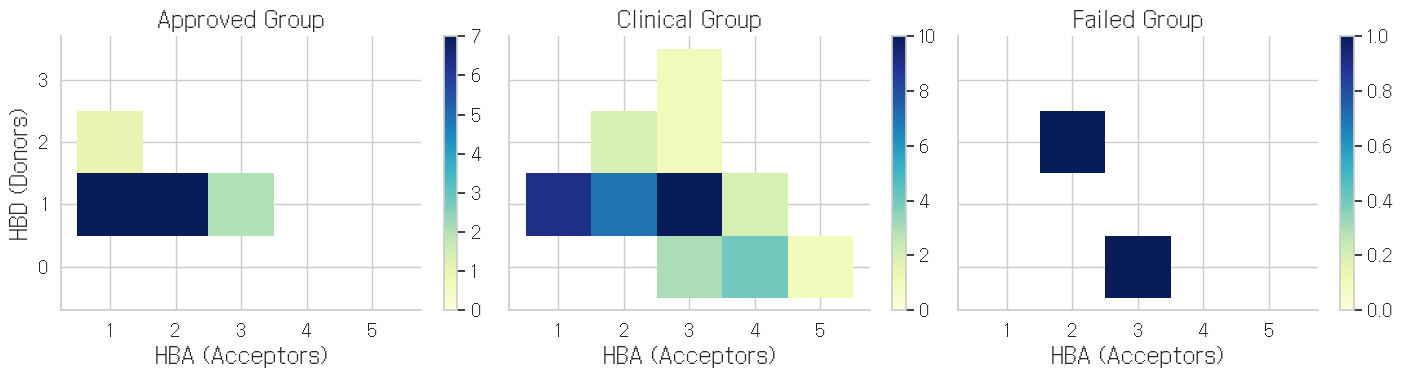

In [67]:
# FacetGrid를 사용해 Status별로 나눠서 보기
g = sns.FacetGrid(data_df, col="Status", height=4, aspect=1.2, col_order=['Approved', 'Clinical', 'Failed'])
g.map_dataframe(sns.histplot, x="HBA", y="HBD", discrete=(True, True), cbar=True, cmap="YlGnBu")

g.set_axis_labels("HBA (Acceptors)", "HBD (Donors)")
g.set_titles("{col_name} Group")
plt.tight_layout()
plt.show()

- 클리니컬은 뭘 많이 시도해서 그런가? 

## RO5 violation

In [68]:
data_df.groupby(['Status','#RO5 Violations']).size() # 분포 왜이래요

Status    #RO5 Violations
Approved  0                  17
Clinical  0                  36
          1                   4
Failed    0                   2
dtype: int64

### 위반하신분 누구시죠

In [75]:
# 이상치를 찾아라 
# 쿼리썼더니 에러나데요... 
idx_list = data_df[data_df['#RO5 Violations'] == 1].index # 2, 13, 21, 57
idx_list
for idx in idx_list:
    display(data_df[['Name','Molecular Weight','Molecular Formula', 'Smiles','HBA','HBD','AlogP']].loc[idx])

Name                                                        LOBUPROFEN
Molecular Weight                                                 429.0
Molecular Formula                                         C25H33ClN2O2
Smiles               CC(C)Cc1ccc(C(C)C(=O)OCCN2CCN(c3cccc(Cl)c3)CC2...
HBA                                                                  4
HBD                                                                  0
AlogP                                                             5.01
Name: 2, dtype: object

Name                                                       FRABUPROFEN
Molecular Weight                                                462.56
Molecular Formula                                         C26H33F3N2O2
Smiles               CC(C)Cc1ccc(C(C)C(=O)OCCN2CCN(c3cccc(C(F)(F)F)...
HBA                                                                  4
HBD                                                                  0
AlogP                                                             5.37
Name: 13, dtype: object

Name                                                      TIOXAPROFEN
Molecular Weight                                               394.28
Molecular Formula                                       C18H13Cl2NO3S
Smiles               CC(Sc1nc(-c2ccc(Cl)cc2)c(-c2ccc(Cl)cc2)o1)C(=O)O
HBA                                                                 4
HBD                                                                 1
AlogP                                                            5.88
Name: 21, dtype: object

Name                                         VEDAPROFEN
Molecular Weight                                 282.38
Molecular Formula                              C19H22O2
Smiles               CC(C(=O)O)c1ccc(C2CCCCC2)c2ccccc12
HBA                                                   1
HBD                                                   1
AlogP                                              5.08
Name: 57, dtype: object

- 뭐가 문제인가 했더니 RO5가 문제였네. 

# 결과

1. 이부프로펜(원조)이 활성에 있어서는 짱이다. 
2. RO5를 위반하지 않고 승인되더라도 부작용때문에 시장에서 퇴출되는 약들이 있다. 

## 이상치 친구들

1. 분자량: fenoprofen calcium
2. 생리활성: Ibuprofen (압도적)
3. AlogP: Lobuprofen, Frabuprofen, Tioxaprofen, Vedaprofen
4. Withdrawn flag: Benoxaprofen, Surprofen, Pirprofen, Indoprofen
    - 이상치까지는 아니고 플래그 선 애들
5. RO5: Lobuprofen, Frabuprofen, Tioxaprofen, Vedaprofen
    - AlogP때문에…